# 03 — Model Training

This notebook builds, trains, and evaluates a custom CNN on the ASL sign language dataset. It also produces training curves, a confusion matrix, and a classification report, and saves the final model to disk.

## Imports

In [1]:
import os
import cv2
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

2026-05-09 18:53:16.504740: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-09 18:53:16.552493: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 18:53:17.595486: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Settings & Seeds

Disable warnings and fix random seeds for reproducibility.

In [2]:
warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams["figure.figsize"] = (10, 6)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Paths

In [3]:
import IPython

NOTEBOOK_DIR = Path(IPython.get_ipython().run_line_magic('pwd', '')).resolve()

BASE_DIR = NOTEBOOK_DIR.parent / "data"

TRAIN_DIR = BASE_DIR / "processed" / "train"
VAL_DIR   = BASE_DIR / "processed" / "val"
TEST_DIR  = BASE_DIR / "processed" / "test"

OUT_DIR = NOTEBOOK_DIR.parent / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Train:", TRAIN_DIR)
print("Val:", VAL_DIR)
print("Test:", TEST_DIR)

Train: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/train
Val: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/val
Test: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/test


## Hyperparameters

In [4]:
IMG_SIZE   = 128
BATCH_SIZE = 64

EPOCHS_CNN = 50

LR_INIT = 1e-3

NUM_CLASSES = 29

AUTOTUNE = tf.data.AUTOTUNE

## Load Datasets

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 4031 files belonging to 29 classes.
Found 870 files belonging to 29 classes.
Found 899 files belonging to 29 classes.
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


2026-05-09 18:53:32.120285: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Normalization Layer

In [6]:
normalization_layer = layers.Rescaling(1./255)

## Data Augmentation

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1)
])

## Apply Preprocessing

In [8]:
def preprocess(x, y):
    x = normalization_layer(x)
    return x, y

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

## Prefetch Pipeline

In [9]:
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

## Model Architecture

A sequential CNN with three Conv2D → MaxPool blocks, followed by a Dense head with Dropout. Augmentation is baked into the model graph.

In [10]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile

Use Adam optimizer with sparse categorical cross-entropy loss.

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_INIT),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training Callbacks

- **EarlyStopping** — stop if `val_loss` stalls for 5 epochs  
- **ModelCheckpoint** — save the best weights by `val_accuracy`  
- **ReduceLROnPlateau** — halve LR when `val_loss` plateaus for 3 epochs

In [12]:
checkpoint_path = OUT_DIR / "best_model.keras"

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3
    )
]

## Train

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 527ms/step - accuracy: 0.0484 - loss: 3.3565 - val_accuracy: 0.1138 - val_loss: 3.2053 - learning_rate: 0.0010
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 524ms/step - accuracy: 0.1226 - loss: 3.1013 - val_accuracy: 0.2874 - val_loss: 2.6627 - learning_rate: 0.0010
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 527ms/step - accuracy: 0.2069 - loss: 2.7037 - val_accuracy: 0.3839 - val_loss: 2.2050 - learning_rate: 0.0010
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.2868 - loss: 2.3573 - val_accuracy: 0.4943 - val_loss: 1.7521 - learning_rate: 0.0010
Epoch 5/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 517ms/step - accuracy: 0.3485 - loss: 2.0710 - val_accuracy: 0.5816 - val_loss: 1.4544 - learning_rate: 0.0010
Epoch 6/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 515ms/step - accuracy: 0.4180 - loss: 1.8596 - val_accuracy: 0.6092 - val_loss: 1.3322 - learning_rate: 0.0010
Epoch 7/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 521ms/step - accuracy: 0.4592 - loss: 1.

## Accuracy Curve

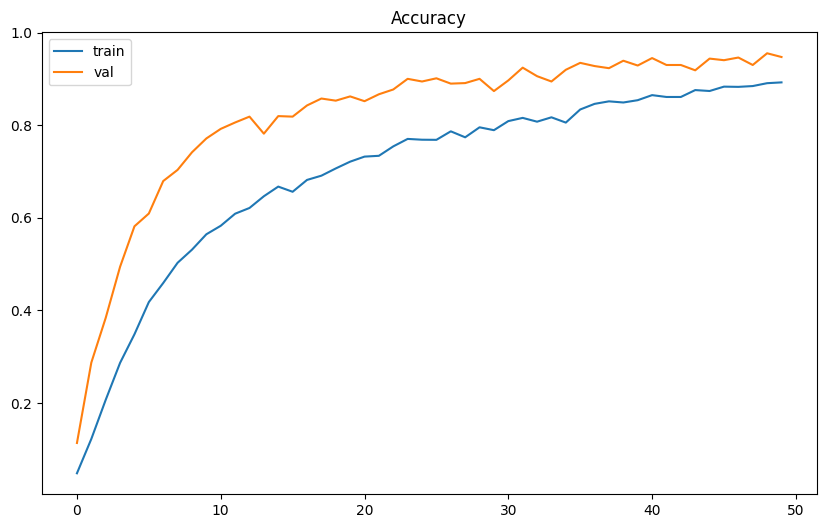

In [14]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

## Loss Curve

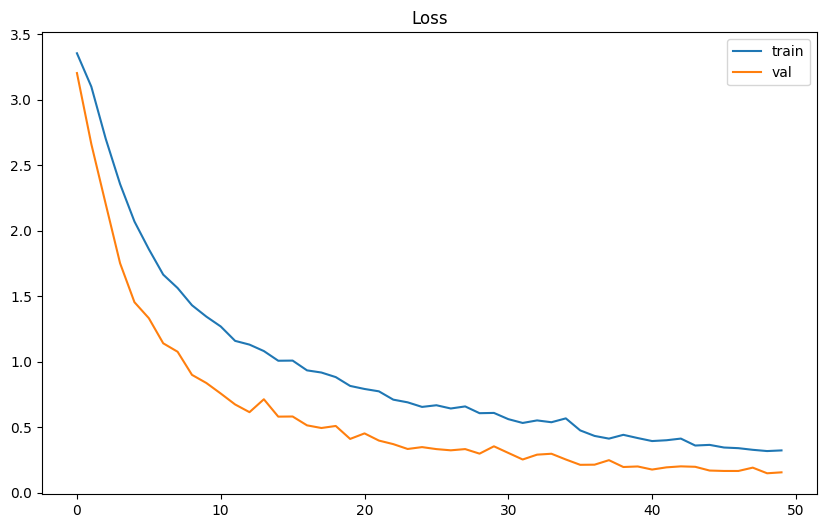

In [15]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

## Test Set Evaluation

In [16]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step - accuracy: 0.9555 - loss: 0.1281
Test accuracy: 0.9555061459541321
Test loss: 0.12806928157806396


## Confusion Matrix

2026-05-09 19:21:52.445231: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


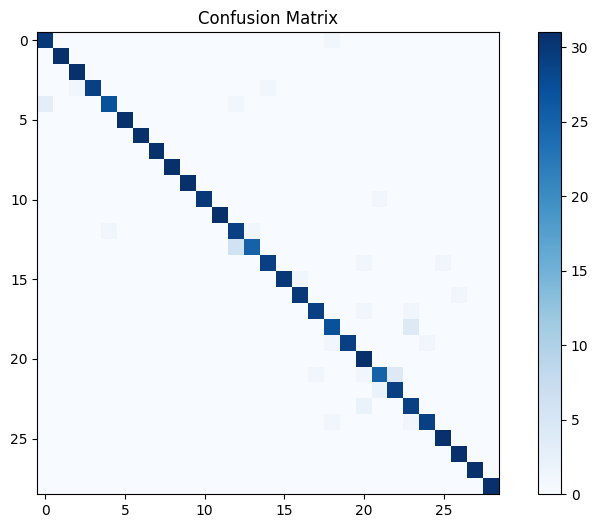

In [17]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

## Classification Report

In [18]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

           A       0.91      0.97      0.94        31
           B       1.00      1.00      1.00        31
           C       0.97      1.00      0.98        31
           D       1.00      0.94      0.97        31
           E       0.96      0.87      0.92        31
           F       1.00      1.00      1.00        31
           G       1.00      1.00      1.00        31
           H       1.00      1.00      1.00        31
           I       1.00      1.00      1.00        31
           J       1.00      1.00      1.00        31
           K       1.00      0.97      0.98        31
           L       1.00      1.00      1.00        31
           M       0.81      0.94      0.87        31
           N       0.96      0.81      0.88        31
           O       0.97      0.94      0.95        31
           P       1.00      0.97      0.98        31
           Q       0.97      0.97      0.97        31
           R       0.97    

## Save Model

In [19]:
model.save(OUT_DIR / "final_model.keras")
print("Model saved.")

Model saved.
